Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3142411367585659..0.9999999999999999].


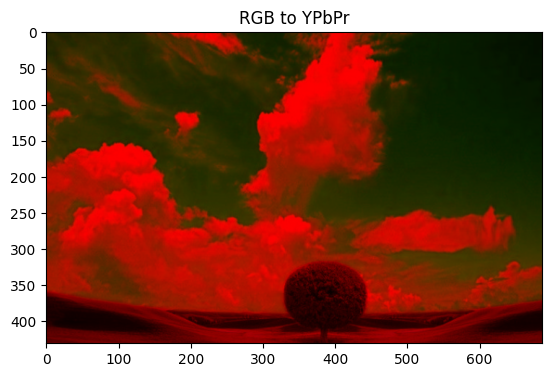

In [1]:
# Program to convert RGB image to YPbPr

# Import OpenCV library
import cv2

# Import NumPy for matrix calculations
import numpy as np

# Import Matplotlib for displaying image
import matplotlib.pyplot as plt

# Read image from file
# OpenCV reads image in BGR format

img = cv2.imread("image.jpg")

# Convert BGR to RGB
# Why?
# Matplotlib expects RGB format

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert pixel values from 0-255 to 0-1
# Required for matrix calculations

rgb = rgb.astype(np.float32) / 255.0

# YPbPr Conversion Matrix
#
# Y  = Brightness (Luminance)
# Pb = Blue difference signal
# Pr = Red difference signal
#
# Used in analog television and video systems

ypbpr_matrix = np.array([
    [0.299,      0.587,      0.114],
    [-0.168736, -0.331264,   0.500000],
    [0.500000,  -0.418688,  -0.081312]
])

# Convert RGB to YPbPr
# .T means transpose of matrix

ypbpr = np.dot(rgb, ypbpr_matrix.T)

# Display image

plt.imshow(ypbpr)
plt.title("RGB to YPbPr")
plt.show()

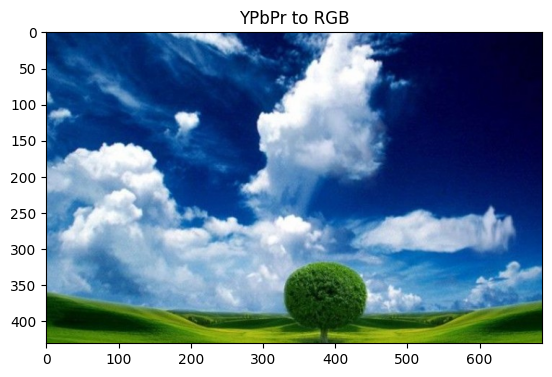

In [2]:
# Program to convert YPbPr image to RGB

# Import OpenCV library
import cv2

# Import NumPy for matrix calculations
import numpy as np

# Import Matplotlib for displaying image
import matplotlib.pyplot as plt

# Read image from file

img = cv2.imread("image.jpg")

# Convert BGR to RGB

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert RGB values to range 0-1

rgb = rgb.astype(np.float32) / 255.0

# YPbPr Conversion Matrix

ypbpr_matrix = np.array([
    [0.299,      0.587,      0.114],
    [-0.168736, -0.331264,   0.500000],
    [0.500000,  -0.418688,  -0.081312]
])

# Convert RGB to YPbPr

ypbpr = np.dot(rgb, ypbpr_matrix.T)

# Find inverse matrix
# Why?
# RGB → YPbPr uses ypbpr_matrix
# YPbPr → RGB uses inverse matrix

inverse_matrix = np.linalg.inv(ypbpr_matrix)

# Convert YPbPr back to RGB

rgb2 = np.dot(ypbpr, inverse_matrix.T)

# Keep values between 0 and 1

rgb2 = np.clip(rgb2, 0, 1)

# Display RGB image

plt.imshow(rgb2)
plt.title("YPbPr to RGB")
plt.show()